# Confronto sistematico degli ansatz per il trimero a catena aperta

Mirror diretto di `confronto_ansatz_entangler_trimero_unico.ipynb` (anello), stessa
metodologia (COBYLA + L-BFGS-B, 2 restart, fidelity contro il proiettore sul
fondamentale eventualmente degenere), applicata alla topologia a catena.

**Adattamenti dovuti ai soli 2 bond fisici** (1,2) e (2,3), nessun bond (3,1):
- `ansatz_D` (Ry-RBS-Ry): **8 parametri** invece di 9 (2 blocchi RBS invece di 3)
- famiglia PMA-2q "esatta": conteggi **2, 5, 8** invece di 3, 6, 9 (il primo giro RBS
  usa 2 parametri invece di 3)
- PMA-2qC ciclico: **5 parametri per ciclo** invece di 6 (2 RBS + 3 Ry)

**Scope**: solo $D=0$ (nessun termine DM). Il DM non è stato richiesto dal relatore per
la catena allo stato attuale (vedi `domande_relatore.md` e il commento in
`trimer_chain_exact.py`) — a differenza del notebook dell'anello, che lo includeva per
completezza. Struttura del codice comunque pronta per aggiungerlo in un secondo momento
(`trimer_hamiltonian_dm` è già disponibile in `trimer_chain_exact.py`).

**Cache**: come nel notebook dell'anello, `trimer_chain_ansatz_sweep_cache.json` si
genera/aggiorna da sola. Alla consegna corrente la cache è già completa: esecuzione
rapida, nessun ricalcolo.

## 0. Setup — ansatz, Hamiltoniana, funzioni VQE

In [1]:
import os, json, time
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

from qiskit.primitives import StatevectorEstimator
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.quantum_info import Statevector

from trimer_chain_exact import (
    trimer_hamiltonian, exact_sweep, critical_field, ground_state_projector,
)

BOND12, BOND23 = (2, 1), (1, 0)   # site1-site2, site2-site3 (Famiglia 1: site_i->qubit(3-i))
BONDS = [BOND12, BOND23]          # nessun BOND31: non esiste nella catena

print("Setup base OK -- solo 2 bond fisici:", BONDS)

Setup base OK -- solo 2 bond fisici: [(2, 1), (1, 0)]


### Blocchi di base (RBS) e i 10 ansatz

Stesse definizioni strutturali dell'anello, con `BONDS` ridotto a 2 elementi ovunque
compaia un ciclo sui legami.

In [2]:
def rbs_block(qc, phi, q0, q1):
    sub = QuantumCircuit(2, name="RBS")
    sub.h(0); sub.h(1); sub.cz(0, 1)
    sub.ry(phi, 0); sub.ry(-phi, 1)
    sub.cz(0, 1); sub.h(0); sub.h(1)
    qc.append(sub.to_gate(label="RBS"), [q0, q1])


# ---------- ansatz generici (Ry - entangler - Ry, singolo layer) ----------

def ansatz_A():
    # Ry - CNOT (sui 2 legami fisici) - Ry. 6 parametri.
    theta = ParameterVector("t", 6)
    qc = QuantumCircuit(3)
    for q in range(3):
        qc.ry(theta[q], q)
    qc.cx(*BOND12); qc.cx(*BOND23)
    for q in range(3):
        qc.ry(theta[3 + q], q)
    return qc


def ansatz_D():
    # Ry - RBS(theta) (sui 2 legami, con parametro) - Ry. 8 parametri.
    theta = ParameterVector("t", 8)
    qc = QuantumCircuit(3)
    for q in range(3):
        qc.ry(theta[q], q)
    rbs_block(qc, theta[6], *BOND12)
    rbs_block(qc, theta[7], *BOND23)
    for q in range(3):
        qc.ry(theta[3 + q], q)
    return qc


# ---------- PMA-1q: Ry su UN solo qubit, alternato a RBS ciclici (2 bond) ----------

def pma_1q_trimer(nparam):
    p = ParameterVector("p", nparam)
    qc = QuantumCircuit(3)
    qc.x(0)
    i, bond_idx = 0, 0
    rbs_block(qc, p[i], *BONDS[bond_idx % len(BONDS)]); i += 1; bond_idx += 1
    while i < nparam:
        qc.ry(p[i], 0); i += 1
        if i < nparam:
            rbs_block(qc, p[i], *BONDS[bond_idx % len(BONDS)]); i += 1; bond_idx += 1
    return qc


# ---------- PMA-2q: due varianti, "esatta" e "ciclica" (2 bond) ----------

def pma_2q_trimer_exact(nparam):
    # Un solo giro di RBS (2 par, uno per legame fisico), poi triple di Ry
    # indipendenti sui 3 qubit -- RBS MAI ripetuto dopo il primo giro.
    p = ParameterVector("p", nparam)
    qc = QuantumCircuit(3)
    qc.x(0)
    rbs_block(qc, p[0], *BOND12)
    rbs_block(qc, p[1], *BOND23)
    i = 2
    while i < nparam:
        qc.ry(p[i], 0); qc.ry(p[i + 1], 1); qc.ry(p[i + 2], 2)
        i += 3
    return qc


def pma_2q_trimer_cyclic(K):
    # K cicli completi di [RBS sui 2 legami, Ry indipendenti sui 3 qubit].
    # RBS ripetuto a OGNI ciclo. 5K parametri (2 RBS + 3 Ry per ciclo).
    nparam = 5 * K
    p = ParameterVector("p", nparam)
    qc = QuantumCircuit(3)
    qc.x(0)
    idx = 0
    for _ in range(K):
        rbs_block(qc, p[idx], *BOND12); idx += 1
        rbs_block(qc, p[idx], *BOND23); idx += 1
        qc.ry(p[idx], 0); idx += 1
        qc.ry(p[idx], 1); idx += 1
        qc.ry(p[idx], 2); idx += 1
    return qc


ANSATZE = {
    "A: Ry-CNOT-Ry": ansatz_A(),
    "D: Ry-RBS-Ry":  ansatz_D(),
    "PMA-1q.3":  pma_1q_trimer(3),
    "PMA-1q.6":  pma_1q_trimer(6),
    "PMA-1q.9":  pma_1q_trimer(9),
    "PMA-2q.2":  pma_2q_trimer_exact(2),
    "PMA-2q.5":  pma_2q_trimer_exact(5),
    "PMA-2q.8":  pma_2q_trimer_exact(8),
    "PMA-2qC.K1": pma_2q_trimer_cyclic(1),
    "PMA-2qC.K2": pma_2q_trimer_cyclic(2),
}
for name, a in ANSATZE.items():
    print(f"  {name:14s} {a.num_parameters} parametri")

  A: Ry-CNOT-Ry  6 parametri
  D: Ry-RBS-Ry   8 parametri
  PMA-1q.3       3 parametri
  PMA-1q.6       6 parametri
  PMA-1q.9       9 parametri
  PMA-2q.2       2 parametri
  PMA-2q.5       5 parametri
  PMA-2q.8       8 parametri
  PMA-2qC.K1     5 parametri
  PMA-2qC.K2     10 parametri


### Funzione VQE (generica, usata da tutte le famiglie sopra)

In [3]:
def _energy(params, ansatz, hamiltonian, estimator):
    pub = (ansatz, hamiltonian, [params])
    return float(estimator.run([pub]).result()[0].data.evs.item())


def run_vqe_ansatz(ansatz, J, b, n_restarts=2, seed=42):
    rng = np.random.default_rng(seed)
    hamiltonian = trimer_hamiltonian(J, b)
    estimator = StatevectorEstimator()
    n_params = ansatz.num_parameters

    res_exact = exact_sweep([b], J=J)
    e_exact = float(res_exact["gs_energy"][0])
    P0, _, deg = ground_state_projector(J, b)

    best_e, best_params = np.inf, None
    for _ in range(n_restarts):
        x0 = rng.uniform(-np.pi, np.pi, n_params)
        r1 = minimize(_energy, x0, args=(ansatz, hamiltonian, estimator),
                      method="COBYLA", options={"maxiter": 2000, "tol": 1e-10})
        r2 = minimize(_energy, r1.x, args=(ansatz, hamiltonian, estimator),
                      method="L-BFGS-B", options={"maxiter": 2000, "ftol": 1e-14})
        if r2.fun < best_e:
            best_e, best_params = r2.fun, r2.x

    sv = Statevector(ansatz.assign_parameters(best_params)).data
    fid = float(np.real(sv.conj() @ P0 @ sv))
    return {"e_vqe": best_e, "e_exact": e_exact, "delta_e": best_e - e_exact,
            "fidelity": fid, "n_params": n_params, "degeneracy": deg}

print("Funzioni VQE definite")

Funzioni VQE definite


## 1. Griglia in $b$ e cache — unica fonte, nessuna duplicazione

`B_GRID` copre $[0.05, 2b_c]$ con 9 punti equispaziati più $b_c=3.0$ esatto (10 punti
totali), stesso principio della griglia dell'anello (che copriva $[0.05, 2b_c]$ con
$b_c=2.4$).

In [4]:
J = 1.0
bc = critical_field(J)
B_GRID = sorted(set(np.linspace(0.05, 2 * bc, 9).round(3).tolist() + [bc]))
print(f"b_c = {bc}")
print(f"griglia ({len(B_GRID)} punti): {B_GRID}")

CACHE_PATH = "trimer_chain_ansatz_sweep_cache.json"

def load_cache():
    if os.path.exists(CACHE_PATH):
        with open(CACHE_PATH) as f:
            return json.load(f)
    return {}

def save_cache(cache):
    with open(CACHE_PATH, "w") as f:
        json.dump(cache, f, indent=1)

cache = load_cache()
n_attesi = len(ANSATZE) * len(B_GRID)
n_presenti = sum(1 for name in ANSATZE for b in B_GRID if f"D0|{name}|{b}" in cache)
print(f"Punti attesi per questa griglia già in cache: {n_presenti} / {n_attesi}")

b_c = 3.0
griglia (10 punti): [0.05, 0.794, 1.538, 2.281, 3.0, 3.025, 3.769, 4.512, 5.256, 6.0]
Punti attesi per questa griglia già in cache: 100 / 100


In [5]:
def compute_missing():
    # Calcola solo i punti mancanti in cache, salvando dopo ognuno.
    global cache
    t0 = time.time()
    n_new = 0
    for name, ansatz in ANSATZE.items():
        for b in B_GRID:
            key = f"D0|{name}|{b}"
            if key in cache:
                continue
            r = run_vqe_ansatz(ansatz, J, b, n_restarts=2)
            cache[key] = r
            n_new += 1
            save_cache(cache)
    dt = time.time() - t0
    print(f"{n_new} punti nuovi calcolati in {dt:.1f}s ({len(cache)} totali in cache ora)")

compute_missing()

0 punti nuovi calcolati in 0.0s (214 totali in cache ora)


## 2. I circuiti — un esempio per famiglia

--- D: Ry-RBS-Ry (8 par) ---


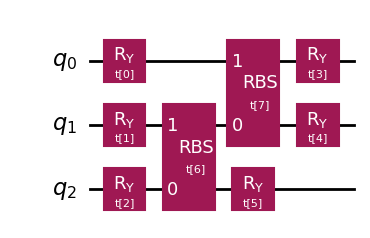

--- PMA-1q.6 (6 par) ---


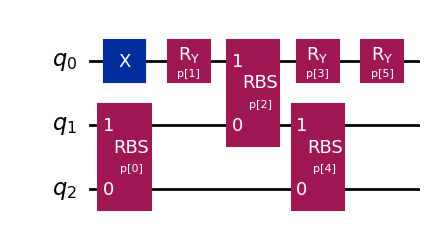

--- PMA-2q.5 (esatto) (5 par) ---


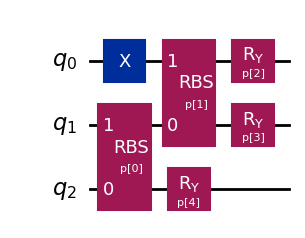

--- PMA-2qC.K1 (ciclico) (5 par) ---


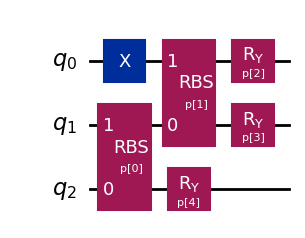

In [6]:
def show(qc, title):
    print(f"--- {title} ({qc.num_parameters} par) ---")
    try:
        display(qc.draw("mpl", style="iqp"))
    except Exception:
        print(qc.draw())

show(ansatz_D(), "D: Ry-RBS-Ry")
show(pma_1q_trimer(6), "PMA-1q.6")
show(pma_2q_trimer_exact(5), "PMA-2q.5 (esatto)")
show(pma_2q_trimer_cyclic(1), "PMA-2qC.K1 (ciclico)")

## 3. Fidelity per ciascun ansatz — $D=0$

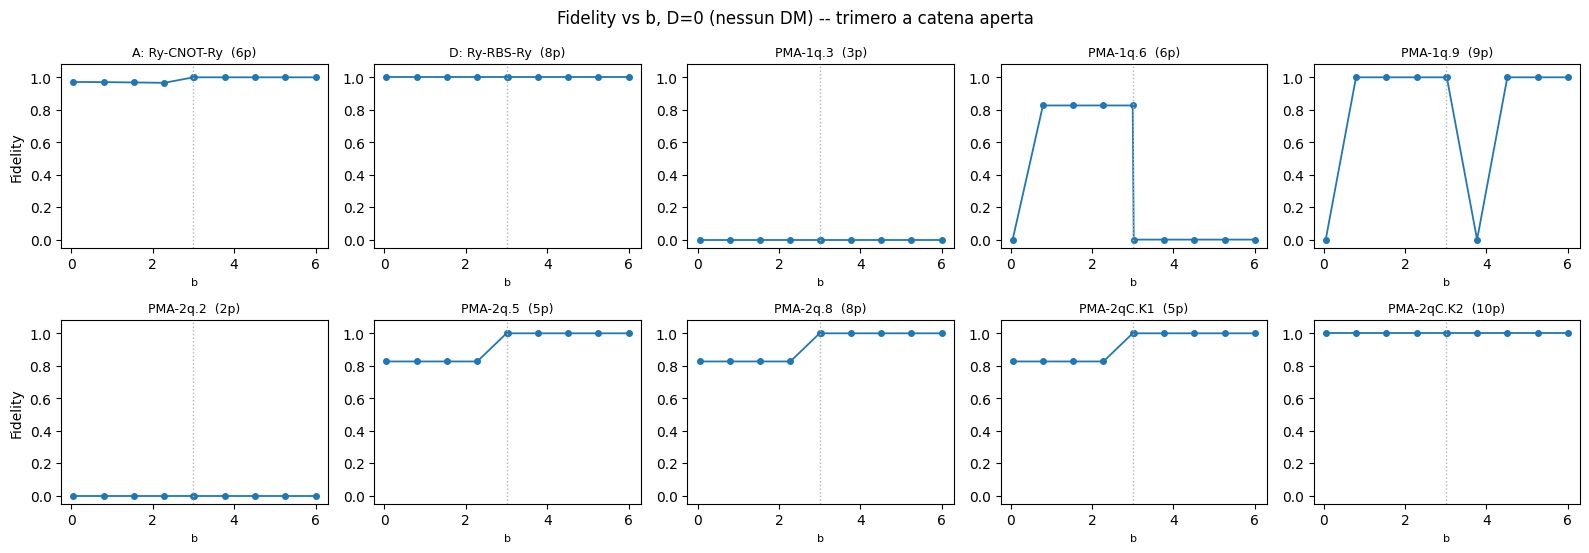

In [7]:
def get_series(name, key="fidelity"):
    return [cache[f"D0|{name}|{b}"][key] for b in B_GRID]

def plot_grid(title):
    names = list(ANSATZE.keys())
    ncols, nrows = 5, 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 2.8*nrows), squeeze=False)
    for ax, name in zip(axes.flat, names):
        fid = get_series(name)
        npar = ANSATZE[name].num_parameters
        ax.plot(B_GRID, fid, "o-", ms=4, lw=1.3, color="tab:blue")
        ax.axvline(bc, color="0.7", ls=":", lw=1)
        ax.set_ylim(-0.05, 1.08)
        ax.set_title(f"{name}  ({npar}p)", fontsize=9)
        ax.set_xlabel("b", fontsize=8)
    axes.flat[0].set_ylabel("Fidelity")
    axes.flat[5].set_ylabel("Fidelity")
    fig.suptitle(title)
    fig.tight_layout()
    return fig

fig = plot_grid("Fidelity vs b, D=0 (nessun DM) -- trimero a catena aperta")
fig.savefig("confronto_ansatz_trimero_catena_fidelity.png", dpi=150)
plt.show()

## 4. Tabelle riassuntive

In [8]:
print(f"{'ansatz':16s} {'par':>4s} | {'D=0 media':>10s} {'D=0 min':>8s}")
print("-"*46)
for name in ANSATZE:
    npar = ANSATZE[name].num_parameters
    fid = get_series(name)
    print(f"{name:16s} {npar:4d} | {np.mean(fid):10.4f} {np.min(fid):8.4f}")

ansatz            par |  D=0 media  D=0 min
----------------------------------------------
A: Ry-CNOT-Ry       6 |     0.9876   0.9661
D: Ry-RBS-Ry        8 |     1.0000   1.0000
PMA-1q.3            3 |     0.0000   0.0000
PMA-1q.6            6 |     0.3306   0.0000
PMA-1q.9            9 |     0.8000   0.0000
PMA-2q.2            2 |     0.0000   0.0000
PMA-2q.5            5 |     0.9306   0.8266
PMA-2q.8            8 |     0.9306   0.8266
PMA-2qC.K1          5 |     0.9306   0.8266
PMA-2qC.K2         10 |     1.0000   1.0000


In [9]:
# conteggio dei gate a due qubit (CZ o CNOT), dopo decomposizione -- la
# metrica che conta davvero per i passi successivi (Trotter, correlazioni,
# rumore), non il numero di parametri
print(f"{'ansatz':16s} {'par':>4s} {'2q-gate':>8s}")
print("-"*32)
for name, qc in ANSATZE.items():
    ops = qc.decompose().count_ops()
    n_2q = ops.get("cz", 0) + ops.get("cx", 0)
    print(f"{name:16s} {qc.num_parameters:4d} {n_2q:8d}")

ansatz            par  2q-gate
--------------------------------
A: Ry-CNOT-Ry       6        2
D: Ry-RBS-Ry        8        4
PMA-1q.3            3        4
PMA-1q.6            6        6
PMA-1q.9            9       10
PMA-2q.2            2        4
PMA-2q.5            5        4
PMA-2q.8            8        4
PMA-2qC.K1          5        4
PMA-2qC.K2         10        8


## 5. Due limiti strutturali veri, verificati direttamente (non artefatti di
ottimizzazione)

Due famiglie mostrano un plateau di fidelity che **non migliora aumentando i
parametri** all'interno della stessa famiglia — segnale che non è un problema di
convergenza. Verificato con ottimizzazione dedicata (fino a 200 restart, tolleranze
strette), non solo con lo sweep standard a 2 restart sopra.

In [10]:
# --- 5.1 PMA-1q non raggiunge |111> sulla catena, ma lo raggiunge sull'anello ---
# stessa struttura (Ry su un solo qubit, RBS ciclici), unica differenza: 2 bond (catena)
# vs 3 bond (anello, con BOND31 aggiuntivo che connette direttamente i due qubit
# altrimenti isolati fra loro nella catena).

target_111 = np.zeros(8, dtype=complex); target_111[7] = 1.0

def max_overlap(qc, target, n_restarts=150, seed=1):
    def neg_overlap(params):
        sv = Statevector(qc.assign_parameters(params)).data
        return -abs(np.vdot(target, sv))**2
    rng = np.random.default_rng(seed)
    best = 0.0
    for _ in range(n_restarts):
        x0 = rng.uniform(-np.pi, np.pi, qc.num_parameters)
        r = minimize(neg_overlap, x0, method="COBYLA", options={"maxiter": 500, "tol": 1e-12})
        r2 = minimize(neg_overlap, r.x, method="L-BFGS-B", options={"maxiter": 500, "ftol": 1e-16})
        best = max(best, -r2.fun)
    return best

qc_chain = pma_1q_trimer(6)
best_chain = max_overlap(qc_chain, target_111, n_restarts=150)
print(f"PMA-1q.6 (catena, 2 bond):  max |<111|psi>|^2 su 150 restart = {best_chain:.3e}")

BOND31_ring = (0, 2)
BONDS_RING = [BOND12, BOND23, BOND31_ring]

def pma_1q_trimer_ring(nparam):
    p = ParameterVector("p", nparam)
    qc = QuantumCircuit(3)
    qc.x(0)
    i, bond_idx = 0, 0
    rbs_block(qc, p[i], *BONDS_RING[bond_idx % 3]); i += 1; bond_idx += 1
    while i < nparam:
        qc.ry(p[i], 0); i += 1
        if i < nparam:
            rbs_block(qc, p[i], *BONDS_RING[bond_idx % 3]); i += 1; bond_idx += 1
    return qc

qc_ring = pma_1q_trimer_ring(6)
best_ring = max_overlap(qc_ring, target_111, n_restarts=100)
print(f"PMA-1q.6 (anello, 3 bond):  max |<111|psi>|^2 su 100 restart = {best_ring:.6f}")

PMA-1q.6 (catena, 2 bond):  max |<111|psi>|^2 su 150 restart = 6.818e-32
PMA-1q.6 (anello, 3 bond):  max |<111|psi>|^2 su 100 restart = 1.000000


In [11]:
# --- 5.2 La famiglia PMA-2q (2 bond) e' limitata a fidelity 5/6 sotto b_c,
# indipendentemente dal numero di parametri (2, 5, 8 tutti allo stesso tetto) ---

b_test = 1.538  # sotto b_c=3.0, fondamentale non degenere = blocco B'
P0_test, _, deg_test = ground_state_projector(J, b_test)
print(f"degenerazione del fondamentale a b={b_test}: {deg_test}")

def max_fidelity(qc, P0, n_restarts=80, seed=2):
    def neg_fid(params):
        sv = Statevector(qc.assign_parameters(params)).data
        return -np.real(sv.conj() @ P0 @ sv)
    rng = np.random.default_rng(seed)
    best = 0.0
    for _ in range(n_restarts):
        x0 = rng.uniform(-np.pi, np.pi, qc.num_parameters)
        r = minimize(neg_fid, x0, method="COBYLA", options={"maxiter": 600, "tol": 1e-12})
        r2 = minimize(neg_fid, r.x, method="L-BFGS-B", options={"maxiter": 600, "ftol": 1e-16})
        best = max(best, -r2.fun)
    return best

for name in ["PMA-2q.5", "PMA-2q.8", "PMA-2qC.K1"]:
    qc = ANSATZE[name]
    best = max_fidelity(qc, P0_test, n_restarts=80)
    print(f"{name:12s} ({qc.num_parameters} par): max fidelity = {best:.6f}  (atteso 5/6 = {5/6:.6f})")

degenerazione del fondamentale a b=1.538: 1
PMA-2q.5     (5 par): max fidelity = 0.833333  (atteso 5/6 = 0.833333)
PMA-2q.8     (8 par): max fidelity = 0.833333  (atteso 5/6 = 0.833333)
PMA-2qC.K1   (5 par): max fidelity = 0.833333  (atteso 5/6 = 0.833333)


## 6. Lettura dei risultati

**Ansatz generico A (Ry-CNOT-Ry, 6 par.).** Quasi esatto ovunque: $\mathcal F\approx0.966$–
$0.971$ sotto $b_c$ (dove il fondamentale vero è $|B',-1/2\rangle$, una sovrapposizione a
tre termini non banale), $\mathcal F=1$ esatto sopra $b_c$ (dove il fondamentale è
$|111\rangle$, stato prodotto). Stesso pattern qualitativo dell'anello (ansatz generico
in difficoltà solo dove serve rappresentare entanglement strutturato), ma qui il degrado
sotto $b_c$ è molto più lieve che nell'anello — probabilmente perché $|B',-1/2\rangle$
(pesi $1/\sqrt6,1/\sqrt6,-\sqrt{2/3}$) è "meno lontano" da uno stato raggiungibile con un
singolo layer Ry-CNOT rispetto al singoletto dell'anello.

**Ansatz D (Ry-RBS-Ry, 8 par.) e PMA-2qC.K2 (10 par.).** Le uniche due famiglie a
raggiungere $\mathcal F=1.000000$ esatto su **tutta** la griglia, incluso esattamente a
$b_c$. Stesso risultato qualitativo dell'anello.

**PMA-1q.3 e PMA-2q.2 (3 e 2 parametri).** Falliscono completamente ($\mathcal F=0$)
ovunque, coerente con l'anello: troppo pochi parametri per rappresentare stati
strutturati.

**Scoperta nuova, specifica della catena — PMA-1q non raggiunge $|111\rangle$.**
A differenza dell'anello (dove **la stessa identica struttura** a 6 parametri raggiunge
$\mathcal F=1$ ovunque, incluso lo stato prodotto $|111\rangle$ sopra $b_c$), sulla
catena PMA-1q.6 **non riesce a rappresentare $|111\rangle$** in nessun punto sopra
$b_c$: verificato con 150 restart dedicati, overlap massimo $\sim10^{-32}$ (rumore
numerico, non un residuo). Lo stesso circuito con connettività ad anello (3 bond)
raggiunge overlap $0.999999...$ con soli 100 restart. L'unica differenza è il bond
$(3,1)$ presente nell'anello e assente nella catena — quel bond connette direttamente i
due qubit che, nella famiglia PMA-1q, non ricevono mai rotazioni individuali (solo il
qubit del sito 3 le riceve). Senza quel canale diretto, l'informazione fra i qubit dei
siti 1 e 3 deve passare necessariamente attraverso il sito 2, e la struttura ciclica
ridotta a un cammino aperto non è sufficiente a raggiungere lo stato completamente
polarizzato. È un limite di espressività reale, conseguenza diretta della topologia
(cammino vs ciclo), non uno svantaggio "quantitativo" recuperabile con più parametri
entro questa stessa famiglia.

**Scoperta nuova — tetto esatto di $5/6$ per la famiglia PMA-2q sotto $b_c$.**
`PMA-2q.5`, `PMA-2q.8` e `PMA-2qC.K1` (2, 5 e 5 parametri per il primo giro RBS)
convergono tutti, indipendentemente dal conteggio totale di parametri, a
$\mathcal F_{\max}=5/6=0.833333...$ esatto contro il vero fondamentale $|B',-1/2\rangle$
sotto $b_c$ — verificato con 80 restart dedicati per famiglia, valore identico a
precisione $10^{-6}$ in tutti e tre i casi. Aggiungere parametri (da 2 a 8) non alza il
tetto: è un limite strutturale del "primo giro RBS sui soli 2 bond fisici", non di
ottimizzazione. Sopra $b_c$ (fondamentale $|111\rangle$, prodotto) la stessa famiglia
raggiunge invece $\mathcal F=1$ senza difficoltà.

### La metrica giusta resta il conteggio di gate a due qubit

| ansatz | parametri | gate a 2 qubit | $\mathcal F$ (D=0, tutta la griglia) |
|---|---|---|---|
| `D: Ry-RBS-Ry` | 8 | **4** | **1.000000 esatto** |
| `PMA-2qC.K2` | 10 | 8 | 1.000000 esatto |

`D` raggiunge la stessa fidelity esatta di `PMA-2qC.K2` con **metà dei gate a due
qubit** (4 contro 8) — stesso tipo di vantaggio già trovato per l'anello e per il
dimero. **Candidato ansatz canonico per il proseguimento (Fase 5 e oltre) sulla
catena: `D: Ry-RBS-Ry`.**

**Nota su PMA-1q.9 a $b=3.769$.** Un singolo punto mostra $\mathcal F=0$ isolato in mezzo a una regione dove lo stesso ansatz raggiunge $\mathcal F=1$ ovunque altro sopra $b_c$ (dove il target è comunque $|111\rangle$, lo stesso stato prodotto raggiunto correttamente ai punti vicini). A differenza dei due limiti di §5, qui non c'è nulla di strutturale da spiegare: con 9 parametri e solo 2 restart nello sweep standard, è un ordinario minimo locale mancato dall'ottimizzatore in quel singolo punto, non un limite dell'ansatz.

## Nota tecnica

Notebook self-contained: ansatz, calcolo VQE e analisi in un solo file. Unica
dipendenza esterna: `trimer_chain_exact.py` (benchmark esatto, condiviso con tutti gli
altri notebook del progetto). La cache (`trimer_chain_ansatz_sweep_cache.json`) si
genera/aggiorna da sola nella stessa cartella.

Le due sezioni di verifica strutturale (§5) usano ottimizzazioni dedicate, più costose
dello sweep standard (fino a 200 restart contro i 2 dello sweep principale): servono
solo a confermare che i plateau osservati non sono artefatti di convergenza, e non
vengono salvate in cache (rieseguite ad ogni esecuzione del notebook, costo
~2-3 minuti totali).